data&imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

X = np.array([[1, 3], [4, 10]], dtype=float)
y = np.array([5, 6], dtype=float)
LEARNING_RATE = 0.01
ITERATIONS = 3

 Model functions

In [2]:
def predict(X, m, b):
    return X @ m + b

def mse(X, y, m, b):
    return np.mean((predict(X, m, b) - y) ** 2)

def gradients(X, y, m, b):
    n = len(y)
    errors = predict(X, m, b) - y
    return (2 / n) * (X.T @ errors), (2 / n) * np.sum(errors)

SciPy derivative check

In [3]:
def scipy_derivative(equation, params, epsilon=1e-8):
    return approx_fprime(params, equation, epsilon)

def cost_of_params(params):
    m, b_val = params[:2], np.full(2, params[2])
    return mse(X, y, m, b_val)

print("SciPy gradient at start:", scipy_derivative(cost_of_params, np.array([-1.0, 2.0, 1.0])))

SciPy gradient at start: [ 44.99999994 113.00000293  12.00000107]


 Gradient descent loop

In [4]:
def gradient_descent(X, y, m_init, b_init, lr, iterations):
    m = np.array(m_init, dtype=float)
    b = np.array(b_init, dtype=float)
    history = {"m": [m.copy()], "b": [b.copy()], "mse": [mse(X, y, m, b)]}
    for i in range(iterations):
        y_hat = predict(X, m, b)
        grad_m, grad_b = gradients(X, y, m, b)
        print(f"--- Iteration {i + 1} ---")
        print(f"Predictions: {y_hat}")
        print(f"Errors:      {y_hat - y}")
        print(f"MSE:         {mse(X, y, m, b):.4f}")
        print(f"grad_m:      {grad_m}")
        print(f"grad_b:      {grad_b:.4f}")
        m = m - lr * grad_m
        b = b - lr * grad_b
        print(f"Updated m:   {m}")
        print(f"Updated b:   {b}\n")
        history["m"].append(m.copy())
        history["b"].append(b.copy())
        history["mse"].append(mse(X, y, m, b))
    return m, b, history

final_m, final_b, history = gradient_descent(X, y, [-1, 2], [1, 1], LEARNING_RATE, ITERATIONS)
print("--- OPTIMIZATION COMPLETE ---")
print(f"Final Optimized m: {final_m}")
print(f"Final Optimized b: {final_b}")

--- Iteration 1 ---
Predictions: [ 6. 17.]
Errors:      [ 1. 11.]
MSE:         61.0000
grad_m:      [ 45. 113.]
grad_b:      12.0000
Updated m:   [-1.45  0.87]
Updated b:   [0.88 0.88]

--- Iteration 2 ---
Predictions: [2.04 3.78]
Errors:      [-2.96 -2.22]
MSE:         6.8450
grad_m:      [-11.84 -31.08]
grad_b:      -5.1800
Updated m:   [-1.3316  1.1808]
Updated b:   [0.9318 0.9318]

--- Iteration 3 ---
Predictions: [3.1426 7.4134]
Errors:      [-1.8574  1.4134]
MSE:         2.7238
grad_m:      [3.7962 8.5618]
grad_b:      -0.4440
Updated m:   [-1.369562  1.095182]
Updated b:   [0.93624 0.93624]

--- OPTIMIZATION COMPLETE ---
Final Optimized m: [-1.369562  1.095182]
Final Optimized b: [0.93624 0.93624]


plots

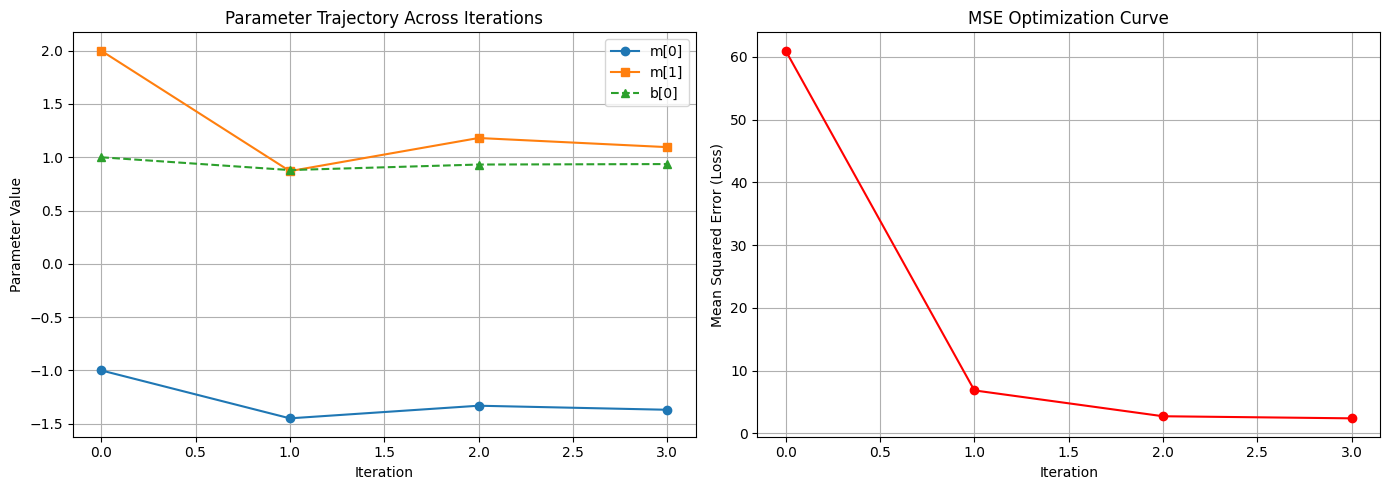

In [5]:
m_hist = np.array(history["m"])
b_hist = np.array(history["b"])
iters = range(len(history["mse"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(iters, m_hist[:, 0], "o-", label="m[0]")
ax1.plot(iters, m_hist[:, 1], "s-", label="m[1]")
ax1.plot(iters, b_hist[:, 0], "^--", label="b[0]")
ax1.set_title("Parameter Trajectory Across Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Parameter Value")
ax1.legend()
ax1.grid(True)

ax2.plot(iters, history["mse"], "ro-")
ax2.set_title("MSE Optimization Curve")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Mean Squared Error (Loss)")
ax2.grid(True)
plt.tight_layout()
plt.show()